Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
weighted_update_path = (
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
weighted_update_df = pd.read_csv(weighted_update_path, low_memory=False)

/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pingouin/correlation.py:134: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to double check your results or use another robust correlation method.
  warnings.warn(
/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pingouin/correlation.py:134: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to double check your res

Cardiac beliefs
           n  outliers         r          CI95         p_val  power
skipped  187        13  0.592234  [0.49, 0.68]  7.489597e-18    1.0
Interoceptive sensitivity
           n  outliers         r          CI95         p_val     power
skipped  187        14  0.365854  [0.23, 0.49]  7.426613e-07  0.998875
Precision cardiac beliefs


/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pingouin/correlation.py:134: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to double check your results or use another robust correlation method.
  warnings.warn(
/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pingouin/correlation.py:134: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to double check your res

           n  outliers        r           CI95     p_val     power
skipped  187        25  0.10633  [-0.05, 0.26]  0.178078  0.271134
Exteroceptive sensitivity
           n  outliers         r         CI95     p_val     power
skipped  187         5  0.335627  [0.2, 0.46]  0.000004  0.996766


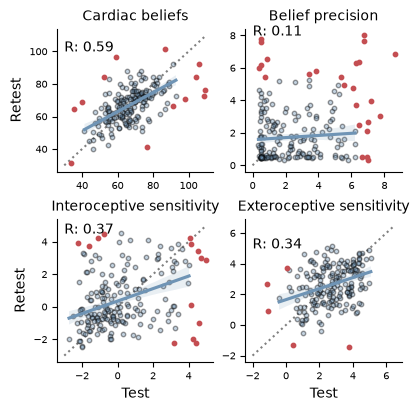

In [3]:
fig, axs = plt.subplots(figsize=(4, 4), ncols=2, nrows=2)

merged = pd.merge(
    weighted_update_df[weighted_update_df.session == 1],
    weighted_update_df[weighted_update_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

r, p, out = pg.correlation.skipped(
    x=merged["cardiac_belief_del1"].to_numpy(),
    y=merged["cardiac_belief_del2"].to_numpy(),
)
sns.regplot(
    x=merged["cardiac_belief_del1"][~out],
    y=merged["cardiac_belief_del2"][~out],
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolor": "k"},
    color="#6f94b5",
    ax=axs[0, 0],
)
axs[0, 0].scatter(
    x=merged["cardiac_belief_del1"][out],
    y=merged["cardiac_belief_del2"][out],
    color="#c44e52",
    s=10,
)
axs[0, 0].annotate(f"R: {round(r, 2)}", (30, 100))
print("Cardiac beliefs")
print(
    pg.corr(
        x=merged["cardiac_belief_del1"].to_numpy(),
        y=merged["cardiac_belief_del2"].to_numpy(),
        method="skipped",
    )
)

# -------------------------------------------------------------------
r, p, out = pg.correlation.skipped(
    x=merged["logit_interoceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_interoceptive_sensitivity_del2"].to_numpy(),
)
sns.regplot(
    x=merged["logit_interoceptive_sensitivity_del1"][~out],
    y=merged["logit_interoceptive_sensitivity_del2"][~out],
    color="#6f94b5",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolor": "k"},
    ax=axs[1, 0],
)
axs[1, 0].scatter(
    x=merged["logit_interoceptive_sensitivity_del1"][out],
    y=merged["logit_interoceptive_sensitivity_del2"][out],
    color="#c44e52",
    s=10,
)
axs[1, 0].annotate(f"R: {round(r, 2)}", (-3, 4.5))
print("Interoceptive sensitivity")
print(
    pg.corr(
        x=merged["logit_interoceptive_sensitivity_del1"].to_numpy(),
        y=merged["logit_interoceptive_sensitivity_del2"].to_numpy(),
        method="skipped",
    )
)

# -------------------------------------------------------------------
r, p, out = pg.correlation.skipped(
    x=merged["pi_cardiac_belief_del1"].to_numpy(),
    y=merged["pi_cardiac_belief_del2"].to_numpy(),
)
sns.regplot(
    x=merged["pi_cardiac_belief_del1"][~out],
    y=merged["pi_cardiac_belief_del2"][~out],
    color="#6f94b5",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolor": "k"},
    ax=axs[0, 1],
)
axs[0, 1].scatter(
    x=merged["pi_cardiac_belief_del1"][out],
    y=merged["pi_cardiac_belief_del2"][out],
    color="#c44e52",
    s=10,
)
axs[0, 1].annotate(f"R: {round(r, 2)}", (0.01, 8))
print("Precision cardiac beliefs")
print(
    pg.corr(
        x=merged["pi_cardiac_belief_del1"].to_numpy(),
        y=merged["pi_cardiac_belief_del2"].to_numpy(),
        method="skipped",
    )
)

# -------------------------------------------------------------------
r, p, out = pg.correlation.skipped(
    x=merged["logit_exteroceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_exteroceptive_sensitivity_del2"].to_numpy(),
)
sns.regplot(
    x=merged["logit_exteroceptive_sensitivity_del1"][~out],
    y=merged["logit_exteroceptive_sensitivity_del2"][~out],
    color="#6f94b5",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolor": "k"},
    ax=axs[1, 1],
)
axs[1, 1].scatter(
    x=merged["logit_exteroceptive_sensitivity_del1"][out],
    y=merged["logit_exteroceptive_sensitivity_del2"][out],
    color="#c44e52",
    s=10,
)
axs[1, 1].annotate(f"R: {round(r, 2)}", (-2, 5))
print("Exteroceptive sensitivity")
print(
    pg.corr(
        x=merged["logit_exteroceptive_sensitivity_del1"].to_numpy(),
        y=merged["logit_exteroceptive_sensitivity_del2"].to_numpy(),
        method="skipped",
    )
)

axs[0, 0].plot((30, 110), (30, 110), linestyle=":", color="gray", zorder=0)
axs[0, 0].tick_params(axis="both", labelsize=7)
axs[0, 0].set_title("Cardiac beliefs", fontsize=10)

axs[1, 0].plot((-3, 5), (-3, 5), linestyle=":", color="gray", zorder=0)
axs[1, 0].tick_params(axis="both", labelsize=7)
axs[1, 0].set_title("Interoceptive sensitivity", fontsize=10)

axs[0, 1].plot((0, 0.4), (0, 0.4), linestyle=":", color="gray", zorder=0)
axs[0, 1].tick_params(axis="both", labelsize=7)
axs[0, 1].set_title("Belief precision", fontsize=10)

axs[1, 1].plot((-2, 6.5), (-2, 6.5), linestyle=":", color="gray", zorder=0)
axs[1, 1].tick_params(axis="both", labelsize=7)
axs[1, 1].set_title("Exteroceptive sensitivity", fontsize=10)

axs[0, 0].set(xlabel=None, ylabel="Retest")
axs[1, 0].set(xlabel="Test", ylabel="Retest")
axs[0, 1].set(xlabel=None, ylabel=None)
axs[1, 1].set(xlabel="Test", ylabel=None)

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_3_reliability.svg")